In [1]:
import sys
import os

# _cmp_dir  = uavsafeplanning/STO_MIQP_Comparison/
# _parent_dir = uavsafeplanning/
_cmp_dir    = os.path.abspath("")
_parent_dir = os.path.dirname(_cmp_dir)
_sto_dir    = os.path.join(_parent_dir, "STO")
_miqp_dir   = os.path.join(_parent_dir, "MIQP")

for _p in [_cmp_dir, _parent_dir, _sto_dir, _miqp_dir]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

# Change CWD to uavsafeplanning/ so relative paths (e.g. traj_gen_utils/data/...) resolve correctly
os.chdir(_parent_dir)

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from traj_gen_utils import MINCO_S3NU

from traj_gen_utils import load_voxel_grid
import pyvista as pv
pv.set_jupyter_backend('html')

# load voxel grid environment
path = "traj_gen_utils/data/forest.txt"
vg = load_voxel_grid(path, padding=0)
vg.plot_pyvista()
grid3D = vg.grid

from traj_gen_utils import astar_3d, visualize

start = (1, 5, 10)
goal = (90, 90, 10)
start_grid_idx = vg.info.to_index(start)
goal_grid_idx = vg.info.to_index(goal)

path_indices = astar_3d(grid3D, start_grid_idx, goal_grid_idx, connectivity=18)
visualize(vg, path_indices)

import pydecomp as pdc
from traj_gen_utils import visualize_voxelgrid_with_path
from traj_gen_utils import reduce_turns_by_los

# prune path to only keep straight line segments
path = reduce_turns_by_los(np.array(path_indices), grid3D)

origin    = np.asarray(vg.info.origin, dtype=np.float64)
occ_idx   = np.argwhere(vg.grid == 1)
obs_np    = (occ_idx + 0.5).astype(np.float64) + origin
path_np   = (np.asarray(path, np.float64) + 0.5) + origin 
box_np    = np.array([[5.0, 5.0, 5.0]], dtype=np.float64)

A_list, b_list = pdc.convex_decomposition_3D(obs_np, path_np, box_np)
# (A_list, b_list) is a list of half-space representations of convex polytopes

visualize_voxelgrid_with_path(vg, path_indices, A_list=A_list, b_list=b_list)


EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

[viz] surf points/cells: 128248 128848
[viz] surf bounds: BoundsTuple(x_min =   0.0,
            x_max = 100.0,
            y_min =   0.0,
            y_max = 100.0,
            z_min =   0.0,
            z_max =  40.0)
[viz] centers min/max: [ 1.5  5.5 10.5] [91.5 90.5 10.5]
[viz] segments: 5


EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

In [2]:
##########################################
### SETUP
##########################################

##########################################
# Environment parameters
##########################################
n_corridors = len(A_list)
n_segments_sto = 5
n_segments_miqp_minco = 10
##########################################
# Dynamic constraints
##########################################
v_max = 2.0  # max velocity in [m/s]
a_max = 1.0  # max acceleration in [m/s^2]
j_max = 0.5  # max jerk in [m/s^3]

##########################################
# Boundary conditions
##########################################
pos_init = path_np[0]                  # Start position in [m]
vel_init = np.array([0.0, 0.0, 0.0])   # Start velocity in [m/s]
acc_init = np.array([0.0, 0.0, 0.0])   # Start acceleration in [m/s^2]
pos_final = path_np[-1]                # Goal position in [m]
vel_final = np.array([0.0, 0.0, 0.0])  # Goal velocity in [m/s]
acc_final = np.array([0.0, 0.0, 0.0])  # Goal acceleration in [m/s^2]

##########################################
# Time initialization
##########################################

# Time initialization for STO

##########################################
# If we want to use the interpolated waypoints_init to make equal n_segments_sto and n_segments_miqp_minco
n_segments_sto = n_segments_miqp_minco
from scipy.interpolate import interp1d
t_path = np.linspace(0, 1, len(path_np))  
t_new = np.linspace(0, 1, n_segments_sto + 1)[1:-1]  # 9 interior point
waypoints_init = np.column_stack([
    np.interp(t_new, t_path, path_np[:, 0]),
    np.interp(t_new, t_path, path_np[:, 1]),
    np.interp(t_new, t_path, path_np[:, 2])
])
##########################################

##########################################
# If we want to use the original waypoints_init
#waypoints_init = path_np[1:-1]  # Exclude start and goal
##########################################

segment_lengths = []    # segment lengths between waypoints
segment_lengths.append(np.linalg.norm(waypoints_init[0] - path_np[0]))  # start to wp0
for i in range(len(waypoints_init) - 1):
    segment_lengths.append(np.linalg.norm(waypoints_init[i+1] - waypoints_init[i]))
segment_lengths.append(np.linalg.norm(path_np[-1] - waypoints_init[-1]))  # last wp to goal
time_init_sto = [length / v_max for length in segment_lengths]
total_time_init_sto = sum(time_init_sto)

# Time initialization for MIQP
delta_x = abs(pos_final[0] - pos_init[0])
delta_y = abs(pos_final[1] - pos_init[1])
delta_z = abs(pos_final[2] - pos_init[2])

# T_v: constant-velocity motion per axis
T_vx = delta_x / v_max if v_max > 0 else 0.0
T_vy = delta_y / v_max if v_max > 0 else 0.0
T_vz = delta_z / v_max if v_max > 0 else 0.0

# T_a: constant-acceleration motion from rest per axis
T_ax = np.sqrt(2.0 * delta_x / a_max) if a_max > 0 and delta_x > 0 else 0.0
T_ay = np.sqrt(2.0 * delta_y / a_max) if a_max > 0 and delta_y > 0 else 0.0
T_az = np.sqrt(2.0 * delta_z / a_max) if a_max > 0 and delta_z > 0 else 0.0

# T_j: constant-jerk motion from rest per axis
T_jx = np.cbrt(6.0 * delta_x / j_max) if j_max > 0 and delta_x > 0 else 0.0
T_jy = np.cbrt(6.0 * delta_y / j_max) if j_max > 0 and delta_y > 0 else 0.0
T_jz = np.cbrt(6.0 * delta_z / j_max) if j_max > 0 and delta_z > 0 else 0.0

# Most restrictive (largest) time scale across all axes and modes
T_max = max(T_vx, T_vy, T_vz,
            T_ax, T_ay, T_az,
            T_jx, T_jy, T_jz)

f = 2.0  # Safety factor (same as 4-MIQP_5th_Order.ipynb)
dt_miqp_minco = (f / n_segments_miqp_minco) * T_max
time_init_miqp_minco = np.full(n_segments_miqp_minco, dt_miqp_minco)

In [3]:
##########################################
# STO Implementation
##########################################

from sto_planner import STOPlanner

# Create STO planner
print("Creating STO planner...")
planner_sto = STOPlanner(
    n_segments=n_segments_sto,
    A_list=A_list,
    b_list=b_list,
    waypoints_init=waypoints_init,
    time_init=time_init_sto,
    v_max=v_max,
    a_max=a_max,
    lambda_jerk=10.0,       # Jerk energy weight (PRIMARY, constant)
    lambda_time=0.02,       # Total time weight  (constant)
    lambda_vel=150.0,       # Velocity penalty   (target / final phase)
    lambda_acc=5.0,         # Acceleration penalty (target / final phase)
    lambda_corridor=1200.0, # Corridor penalty   (target / final phase)
    learn_rate=0.05,
    max_iter=50,
    verbose=True,
    adaptive_weights=True,  # Sequential penalty escalation (same as STO.ipynb)
    weight_phases=3,        # 3 phases → iters split ~17/17/16
    weight_scale_factor=5.0 # weights × 5 at each phase transition
)

# Solve trajectory optimization for STO
print("Solving STO trajectory optimization...")
planner_sto.solve(
    pos_init=pos_init,
    vel_init=vel_init,
    acc_init=acc_init,
    pos_final=pos_final,
    vel_final=vel_final,
    acc_final=acc_final
)


##########################################
### Fair Time Allocation for MIQP
# Use STO's optimized total time as MIQP's fixed time budget so that both
# methods operate over the same trajectory duration — enabling a direct
# comparison of jerk cost and constraint satisfaction.
##########################################

from utils import tau_to_time

T_sto_optimized = tau_to_time(planner_sto.tau).detach().numpy()[0, :, 0].sum()
dt_miqp_minco   = T_sto_optimized / n_segments_miqp_minco
time_init_miqp_minco = np.full(n_segments_miqp_minco, dt_miqp_minco)

print(f"\n{'='*60}")
print(f"FAIR TIME ALLOCATION")
print(f"{'='*60}")
print(f"  Kinematic T_max (reference): {(f / n_segments_miqp_minco) * T_max * n_segments_miqp_minco:.2f} s")
print(f"  STO optimized T_total:       {T_sto_optimized:.2f} s  ← used for MIQP")
print(f"  MIQP dt per segment:         {dt_miqp_minco:.3f} s")
print(f"{'='*60}")


##########################################
### MINCO-MIQP Implementation
##########################################

from miqp_planner import MIQPMincoPlanner

# Create MIQP planner with STO's optimized total time
print("Creating MIQP planner...")
planner_miqp_minco = MIQPMincoPlanner(
    n_segments=n_segments_miqp_minco,
    A_list=A_list,
    b_list=b_list,
    time_allocation=time_init_miqp_minco,
    v_max=v_max,
    a_max=a_max,
    verbose=True,
    time_limit=40.0,
    threads=4
)

# Solve trajectory optimization for MIQP
print("\nSolving MIQP...")
planner_miqp_minco.solve(
    pos_init=pos_init,
    vel_init=vel_init,
    acc_init=acc_init,
    pos_final=pos_final,
    vel_final=vel_final,
    acc_final=acc_final
)


##########################################
# Check success
##########################################
if planner_sto.solved:
    print("\n STO SUCCESS!")
else:
    print("\n STO FAILED!")

if planner_miqp_minco.solved:
    print("\n MINCO-MIQP SUCCESS!")
else:
    print("\n MINCO-MIQP FAILED!")

Creating STO planner...


/home/okanarif/repositories/CopySemesterThesis/uavsafeplanning/STO/sto_planner.py:146: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  self.waypoints = torch.tensor([waypoints_init], dtype=torch.float32, requires_grad=True)


Solving STO trajectory optimization...
STO TRAJECTORY OPTIMIZATION
Segments:       10
Waypoints:      9
Max iterations: 50
Corridor cost:  L2 penalty
Adaptive weights: ON  (3 phases, ×5.0 per phase)

Objective weights (fixed):
  λ_jerk     = 10.00
  λ_time     = 0.02

Constraint weights (phase 1 / final target):
  λ_vel      = 6.00  →  150.00
  λ_acc      = 0.20  →  5.00
  λ_corridor = 48.00  →  1200.00  [L2]

Iter | Phase |        Total |       Jerk |     Time |        Vel |        Acc |       Corr
--------------------------------------------------------------------------------------------------
   1 |     1 |   101.184242 |   9.902054 |    63.64 |   0.133699 |   0.016592 |   0.001778
   5 |     1 |     1.701399 |   0.010138 |    79.31 |   0.001793 |   0.000000 |   0.000063
  10 |     1 |     1.649989 |   0.011444 |    75.88 |   0.002997 |   0.000000 |   0.000000
  15 |     1 |     1.649989 |   0.011444 |    75.88 |   0.002997 |   0.000000 |   0.000000

  ── Phase 2/3: λ_vel=30.0  λ_a


Extracting results...

COMPREHENSIVE TRAJECTORY COMPARISON


TRAJECTORY OPTIMIZATION COMPARISON
Method               | Runtime (s)  | Jerk Cost    | Traj Time (s) 
--------------------------------------------------------------------------------
STO                  |       13.977 |     0.011722 |          77.56
MIQP                 |       32.221 |     0.038899 |          77.56

CONSTRAINT VIOLATIONS (Max)
Method               | Velocity     | Acceleration   | Jerk         | Corridor    
--------------------------------------------------------------------------------
STO                  |     0.012752 |       0.000000 |     0.000000 |     0.007118
MIQP                 |     0.000000 |       0.000000 |     0.000000 |     0.000000

Generating dynamic profile comparison...


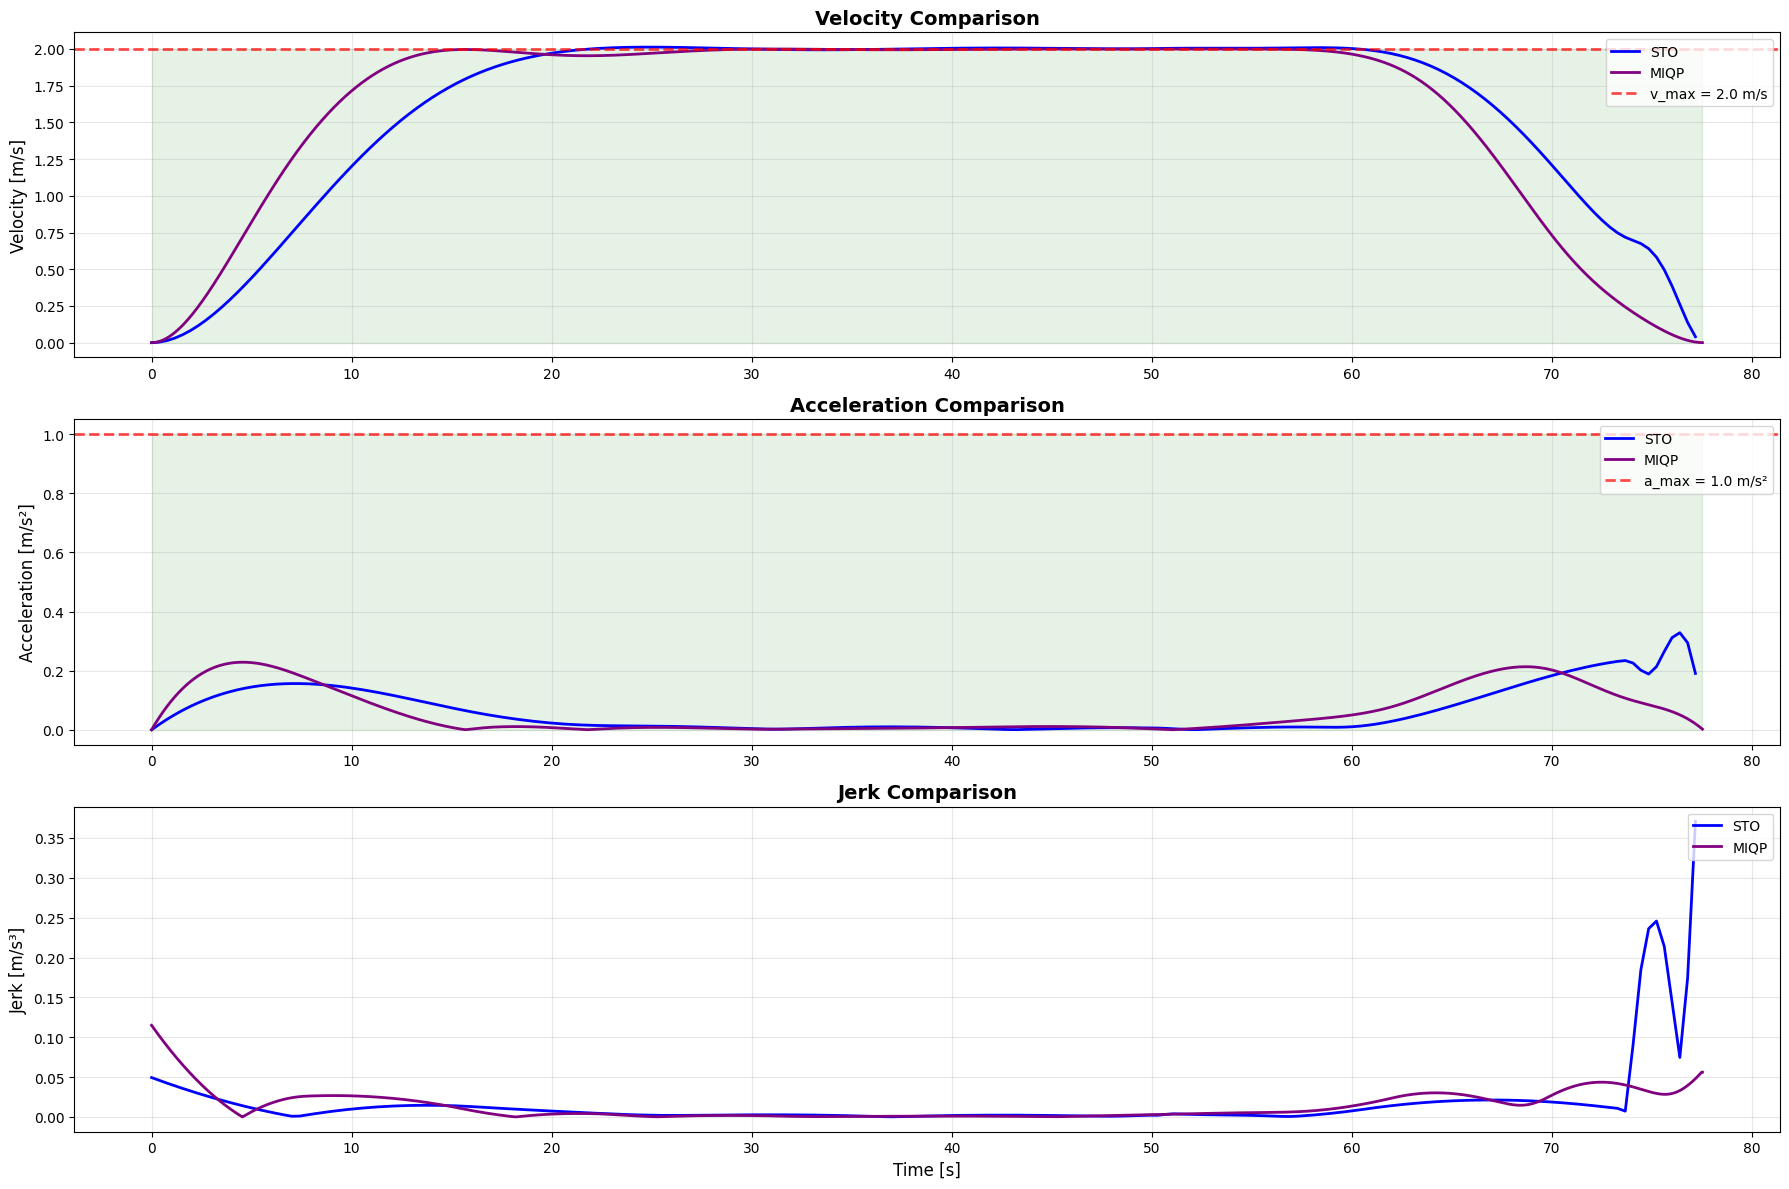

Generating 3D trajectory comparison...


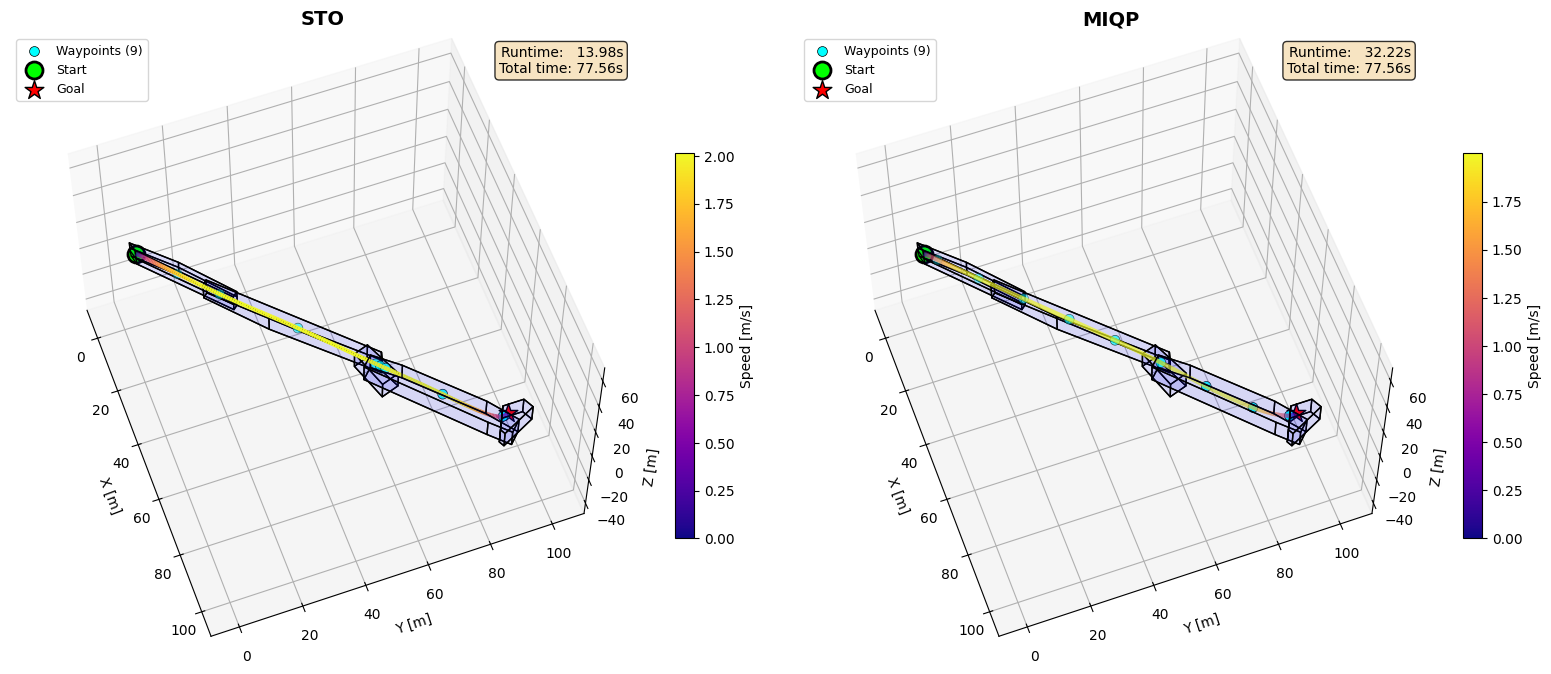

Generating orthogonal views (XY, XZ, YZ)...


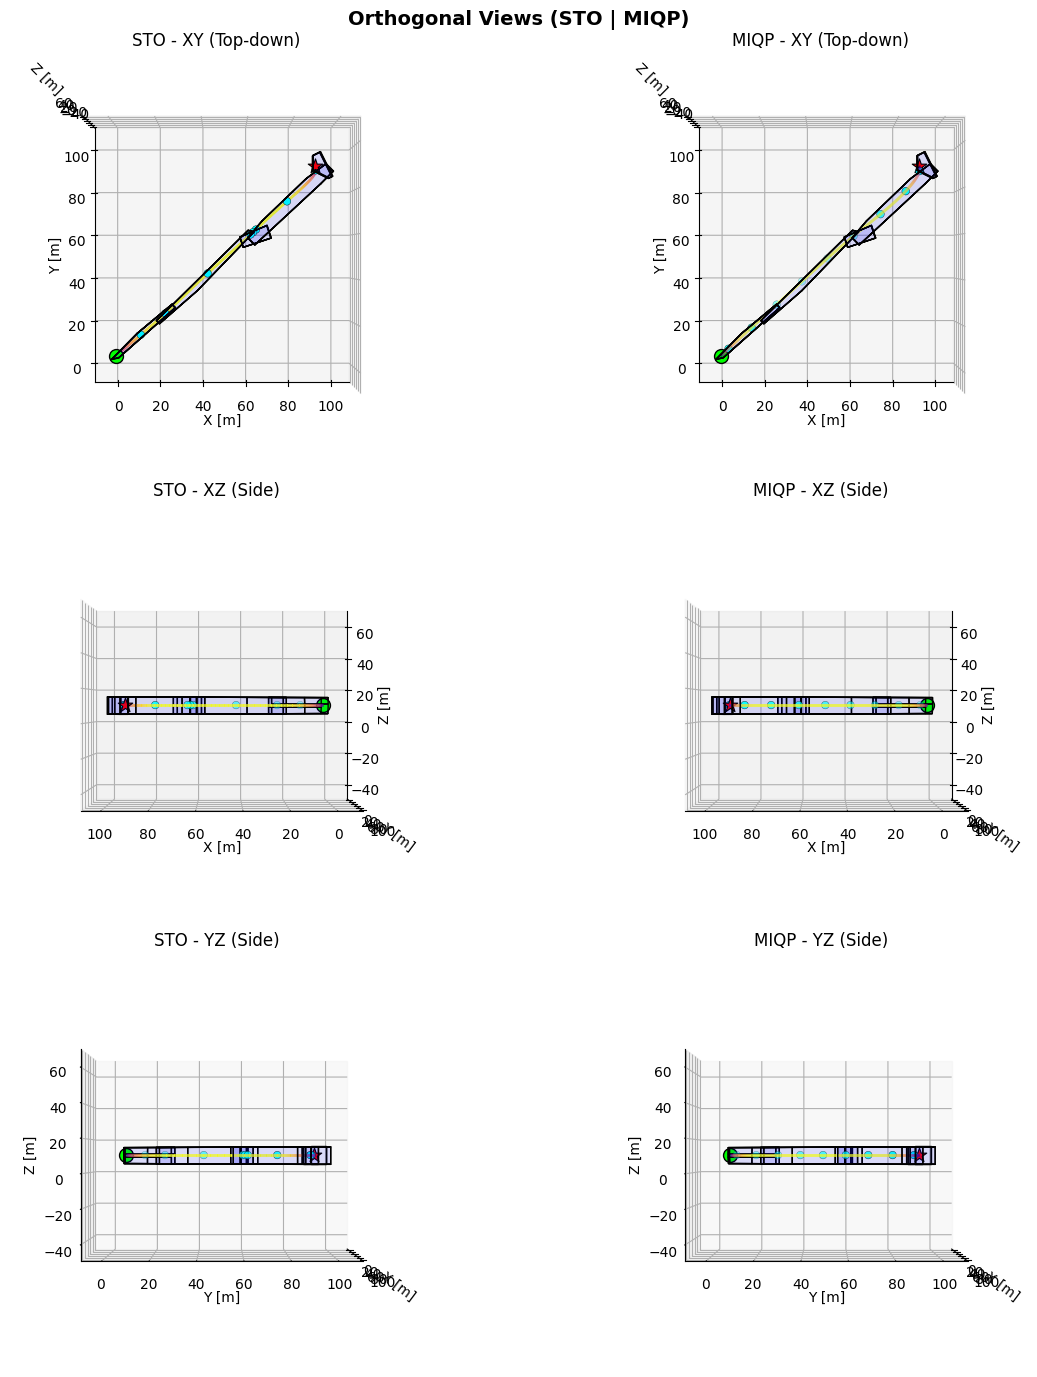


COMPARISON COMPLETE!



In [4]:
##########################################
# Visualize results
##########################################

from comparison_visualiser import visualize_comparison

# Extract results from both planners
print("\nExtracting results...")
results_sto = planner_sto.get_results(n_samples=200)
results_miqp_minco = planner_miqp_minco.get_results(n_samples=200)

# Create comparison dictionary
results_dict = {
    'STO': results_sto,
    'MIQP': results_miqp_minco
}


# Comprehensive comparison
# Note: j_max is not passed because jerk is unconstrained in both STO and MIQP
visualize_comparison(
    results_dict=results_dict,
    A_list=A_list,
    b_list=b_list,
    start=pos_init,
    goal=pos_final,
    v_max=v_max,
    a_max=a_max
)